<a href="https://colab.research.google.com/github/AjitpalSingh1/MLPractice/blob/main/Demo_1_Friday_Final_(5)_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("GoAutoServices.csv")
df.head()

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
0,7/29/2024 0:00,21-Apr,1,0,2021,TOYO,RAV4HY,3395527356,Yes,200-300,True,39076,Toyota on the Trail,9.0
1,7/30/2024 0:00,23-Dec,1,1,2024,TOYO,RAV4HY,5296888873,Yes,0-100,True,39556,Toyota on the Trail,12.0
2,7/2/2024 0:00,20-Mar,1,1,2020,LAND,RR,9475224721,No,1300-1400,True,66001,Jaguar Land Rover Edmonton,10.8
3,7/3/2024 0:00,23-Jul,1,1,2018,NISS,PATH,3446880696,No,500-600,True,82454,Go Nissan South,15.3
4,10/30/2022 0:00,11-May,1,0,2008,FORD,FUSN,5577514554,No,0-100,True,5,Kentwood Ford,4.8


Checking the size of the dataset

In [ ]:
df.shape

(242818, 14)

Getting the information of the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242818 entries, 0 to 242817
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   service_date  242818 non-null  object 
 1   sale_date     242818 non-null  object 
 2   customer_pay  242818 non-null  int64  
 3   warranty_pay  242818 non-null  int64  
 4   year          242818 non-null  int64  
 5   make          242818 non-null  object 
 6   model         242818 non-null  object 
 7   vin           242818 non-null  int64  
 8   loyalty_card  242813 non-null  object 
 9   cost          240095 non-null  object 
 10  appointment   242818 non-null  bool   
 11  mileage       242818 non-null  int64  
 12  dealer_name   242818 non-null  object 
 13  distance      242818 non-null  float64
dtypes: bool(1), float64(1), int64(5), object(7)
memory usage: 24.3+ MB


Making A copy of the dataset

In [ ]:
goauto_df=df.copy()

Checking the datatype of each column

In [ ]:
goauto_df.dtypes

,0
service_date,object
sale_date,object
customer_pay,int64
warranty_pay,int64
year,int64
make,object
model,object
vin,int64
loyalty_card,object
cost,object


Getting the value of cost

In [ ]:
goauto_df['cost'] = goauto_df['cost'].apply(lambda v: v if pd.isna(v) or isinstance(v, (int, float))
      else (float(v.split('-')[0]) + float(v.split('-')[1])) / 2)

As the datatype of cost is object so we covert it to numeric

In [ ]:
goauto_df['cost'] = pd.to_numeric(goauto_df['cost'])

Checking and droping the duplicates

In [ ]:
goauto_df.duplicated().sum()

np.int64(4)

Here we checked the detected duplicates to see if they are really duplicates or just same values but with different VIN before droping.

In [ ]:
goauto_df[goauto_df.duplicated(keep=False)]

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
42783,12/3/2022 0:00,16-Sep,1,0,2016,HOND,ODYS,1357915488,No,50.0,True,109318,Go Honda,8.0
42784,12/3/2022 0:00,16-Sep,1,0,2016,HOND,ODYS,1357915488,No,50.0,True,109318,Go Honda,8.0
68571,3/11/2022 0:00,18-Sep,1,1,2018,NISS,MURAN,8857225517,No,850.0,True,102599,Go Nissan South,26.8
68572,3/11/2022 0:00,18-Sep,1,1,2018,NISS,MURAN,8857225517,No,850.0,True,102599,Go Nissan South,26.8
137893,10/9/2023 0:00,15-Mar,1,0,2015,PORS,911,9842861654,No,350.0,True,31995,Porsche Centre Edmonton,12.0
137894,10/9/2023 0:00,15-Mar,1,0,2015,PORS,911,9842861654,No,350.0,True,31995,Porsche Centre Edmonton,12.0
162721,10/13/2023 0:00,18-Nov,1,0,2018,JAGU,FPACE,3511913766,No,50.0,False,45826,Jaguar Land Rover Edmonton,20.8
162722,10/13/2023 0:00,18-Nov,1,0,2018,JAGU,FPACE,3511913766,No,50.0,False,45826,Jaguar Land Rover Edmonton,20.8


DROP

In [ ]:
goauto_df.drop_duplicates(inplace=True)

Checking for the null values

In [ ]:
goauto_df.isnull().sum()

,0
service_date,0
sale_date,0
customer_pay,0
warranty_pay,0
year,0
make,0
model,0
vin,0
loyalty_card,5
cost,2723


Transforming the missing values in the cost column by median

In [ ]:
goauto_df['cost'] = goauto_df['cost'].fillna(goauto_df.groupby('customer_pay')['cost'].transform('median'))

Checking for the null values again

In [ ]:
goauto_df.isnull().sum()

,0
service_date,0
sale_date,0
customer_pay,0
warranty_pay,0
year,0
make,0
model,0
vin,0
loyalty_card,5
cost,0


Filling the missing values for loyalty card.

In [ ]:
goauto_df['loyalty_card'] = goauto_df['loyalty_card'].fillna('Unknown')

Counting the values to see how many people taped and how many didn't.

In [ ]:
goauto_df['loyalty_card'].value_counts()


,count
loyalty_card,
No,199835
Yes,42974
Unknown,5


Coverting the cost from float to int. If we use the formula like divide by 2, it changes the data type of cost to float automatically.

In [ ]:
goauto_df['cost'] = goauto_df['cost'].round().astype(int)

Checking for missing values in the Service date column

In [ ]:
goauto_df['service_date'].isna().sum()

np.int64(0)

Converting the serice date to datetime.

In [ ]:
goauto_df['service_date'] = pd.to_datetime(goauto_df['service_date'], errors='coerce')

goauto_df.head(21004)

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance
0,2024-07-29,21-Apr,1,0,2021,TOYO,RAV4HY,3395527356,Yes,250,True,39076,Toyota on the Trail,9.0
1,2024-07-30,23-Dec,1,1,2024,TOYO,RAV4HY,5296888873,Yes,50,True,39556,Toyota on the Trail,12.0
2,2024-07-02,20-Mar,1,1,2020,LAND,RR,9475224721,No,1350,True,66001,Jaguar Land Rover Edmonton,10.8
3,2024-07-03,23-Jul,1,1,2018,NISS,PATH,3446880696,No,550,True,82454,Go Nissan South,15.3
4,2022-10-30,11-May,1,0,2008,FORD,FUSN,5577514554,No,50,True,5,Kentwood Ford,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20999,2024-10-13,20-Feb,1,0,2020,FORD,RANGF,9629015215,No,150,True,71384,Kentwood Ford,5.6
21000,2024-10-21,20-Aug,1,0,2020,FORD,RANGF,4203598163,No,2550,True,129972,Kentwood Ford,173.6
21001,NaT,11-Jul,1,0,2008,FORD,RANGF,4373140714,No,250,True,164176,Kentwood Ford,6.0
21002,2022-03-02,19-Sep,1,0,2019,FORD,RANGF,9898946670,No,150,True,40005,Kentwood Ford,14.5


Droping the row with wrong date "1900" was the year for it

In [ ]:
goauto_df = goauto_df.dropna(subset=['service_date'])

Coverting the service date to year and month to generate some more usefull insights.

In [ ]:
goauto_df['service Year'] = goauto_df['service_date'].dt.year
goauto_df['service Month'] = goauto_df['service_date'].dt.month
goauto_df['service day'] = goauto_df['service_date'].dt.day
goauto_df.head()

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance,service Year,service Month,service day
0,2024-07-29,21-Apr,1,0,2021,TOYO,RAV4HY,3395527356,Yes,250,True,39076,Toyota on the Trail,9.0,2024,7,29
1,2024-07-30,23-Dec,1,1,2024,TOYO,RAV4HY,5296888873,Yes,50,True,39556,Toyota on the Trail,12.0,2024,7,30
2,2024-07-02,20-Mar,1,1,2020,LAND,RR,9475224721,No,1350,True,66001,Jaguar Land Rover Edmonton,10.8,2024,7,2
3,2024-07-03,23-Jul,1,1,2018,NISS,PATH,3446880696,No,550,True,82454,Go Nissan South,15.3,2024,7,3
4,2022-10-30,11-May,1,0,2008,FORD,FUSN,5577514554,No,50,True,5,Kentwood Ford,4.8,2022,10,30


Droping the row that was wrong for the service date

In [ ]:
goauto_df = goauto_df.dropna(subset=['service Year', 'service Month'])

Changing the datatype of year and month to integer

In [ ]:
goauto_df['service Year'] = goauto_df['service Year'].astype('Int64')
goauto_df['service Month'] = goauto_df['service Month'].astype('Int64')

In [ ]:
goauto_df.dtypes

,0
service_date,datetime64[ns]
sale_date,object
customer_pay,int64
warranty_pay,int64
year,int64
make,object
model,object
vin,int64
loyalty_card,object
cost,int64


Creating a new column names Month_Name which will further help to generate some good insights with Month names.

In [ ]:
goauto_df["Month_Name"] = goauto_df["service_date"].dt.month_name()
goauto_df.head(242818)

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance,service Year,service Month,service day,Month_Name
0,2024-07-29,21-Apr,1,0,2021,TOYO,RAV4HY,3395527356,Yes,250,True,39076,Toyota on the Trail,9.0,2024,7,29,July
1,2024-07-30,23-Dec,1,1,2024,TOYO,RAV4HY,5296888873,Yes,50,True,39556,Toyota on the Trail,12.0,2024,7,30,July
2,2024-07-02,20-Mar,1,1,2020,LAND,RR,9475224721,No,1350,True,66001,Jaguar Land Rover Edmonton,10.8,2024,7,2,July
3,2024-07-03,23-Jul,1,1,2018,NISS,PATH,3446880696,No,550,True,82454,Go Nissan South,15.3,2024,7,3,July
4,2022-10-30,11-May,1,0,2008,FORD,FUSN,5577514554,No,50,True,5,Kentwood Ford,4.8,2022,10,30,October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242813,2023-09-18,23-Feb,1,0,2020,FORD,F150,1813236058,Yes,1450,True,104768,Kentwood Ford,10.2,2023,9,18,September
242814,2020-04-17,17-Aug,1,0,2017,FORD,F150,6891633666,No,350,False,99848,Kentwood Ford,4.0,2020,4,17,April
242815,2021-02-12,15-May,1,0,2015,FORD,F150,1516333102,No,350,False,110669,Kentwood Ford,24.4,2021,2,12,February
242816,2021-01-20,19-Jan,1,0,2018,FORD,F150,5245369000,No,250,False,66496,Kentwood Ford,5.7,2021,1,20,January


Reseting the index according to service year and month

In [ ]:
goauto_df = goauto_df.sort_values(by=["service Year", "service Month", "dealer_name"]).reset_index(drop=True)
goauto_df.head(242818)

,service_date,sale_date,customer_pay,warranty_pay,year,make,model,vin,loyalty_card,cost,appointment,mileage,dealer_name,distance,service Year,service Month,service day,Month_Name
0,2020-01-18,16-Mar,1,0,2015,FORD,EDGE,3262659922,No,750,True,152310,Go Honda,18.8,2020,1,18,January
1,2020-01-11,19-May,1,0,2014,FORD,ESCAP,8242465380,No,50,True,111531,Go Honda,18.6,2020,1,11,January
2,2020-01-29,19-Sep,1,0,2014,HYUN,SANT,5457946460,No,50,True,103234,Go Honda,27.2,2020,1,29,January
3,2020-01-21,18-Jun,1,0,2013,HYUN,ELAN,2763229736,No,1050,True,150117,Go Honda,16.9,2020,1,21,January
4,2020-01-22,14-Oct,1,1,2011,HOND,CRV,5481666998,No,250,True,164734,Go Honda,11.6,2020,1,22,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242808,2024-12-01,24-Jul,0,1,2024,TOYO,RAV4,5576831513,Yes,50,True,22767,Toyota on the Trail,4.9,2024,12,1,December
242809,2024-12-13,24-Jun,0,1,2024,TOYO,RAV4,3694557226,Yes,150,True,7910,Toyota on the Trail,10.5,2024,12,13,December
242810,2024-12-13,23-Dec,0,1,2024,TOYO,RAV4,5969427391,Yes,50,True,24029,Toyota on the Trail,9.7,2024,12,13,December
242811,2024-12-11,23-Dec,1,0,2018,HYUN,SANTA,4138062302,Yes,150,True,129970,Toyota on the Trail,12.7,2024,12,11,December


In [ ]:
 goauto_df = goauto_df.drop(df.index[242812])

First we created a column in which we added both year and month to get monthly and yearly insights.

In [ ]:
goauto_df["YearMonth"] = goauto_df["service Year"].astype(str) + '-' + goauto_df["service Month"].astype(str) .str.zfill(2)

For finding the gross service revenue by month

In [ ]:
monthly_revenue = (goauto_df.groupby('YearMonth')['cost'].sum().reset_index(name='Gross_monthly_revenue'))
monthly_revenue.head(13)

,YearMonth,Gross_monthly_revenue
0,2020-01,2056350
1,2020-02,1884450
2,2020-03,1888400
3,2020-04,1249800
4,2020-05,2298000
5,2020-06,2445850
6,2020-07,2197650
7,2020-08,2218800
8,2020-09,2169100
9,2020-10,2627750


Dealer wise revenue

In [ ]:
dealer_revenue = (goauto_df.groupby('dealer_name')['cost'].sum().reset_index(name='Gross_monthly_revenue_dealer'))
dealer_revenue.head()

,dealer_name,Gross_monthly_revenue_dealer
0,Go Honda,20156350
1,Go Nissan South,12255150
2,Jaguar Land Rover Edmonton,30628800
3,Kentwood Ford,18503350
4,Norden Volkswagen,25546350


We grouped these columns so we can use them to get our no. of serices per month for each dealer.

In [ ]:
group_cols = ["dealer_name", "service Year", "service Month"]

Number of services per month

In [ ]:
number_of_services = goauto_df.groupby(group_cols).size().reset_index(name="Number_of_services")
number_of_services.head()

,dealer_name,service Year,service Month,Number_of_services
0,Go Honda,2020,1,904
1,Go Honda,2020,2,829
2,Go Honda,2020,3,733
3,Go Honda,2020,4,523
4,Go Honda,2020,5,917


Average gross per service according to month

In [ ]:
avg_gross_per_service = (goauto_df.groupby('YearMonth')['cost'].mean().reset_index(name='Avg_gross_per_service'))
avg_gross_per_service.head()

,YearMonth,Avg_gross_per_service
0,2020-01,489.257673
1,2020-02,507.801132
2,2020-03,548.634515
3,2020-04,488.584832
4,2020-05,523.224044


In [ ]:
goauto_df['make'].unique()

array(['FORD', 'HYUN', 'HOND', 'NISS', 'TOYO', 'DODG', 'MAZD', 'CHRY',
       'AUDI', 'GMC', 'ACUR', 'SUBA', 'BUIC', 'MB', 'MERZ', 'ROVE', 'BMW',
       'FIAT', 'MITS', 'KIA', 'CHEV', 'INFI', 'LAND', 'JAGU', 'LINC',
       'VW', 'INTL', 'JEEP', 'BENZ', 'HUMM', 'PORS', 'RAMT', 'LEXU',
       'CADI', 'LANDR', 'VOLV', 'MLT', 'MINI', 'LROVER', 'BENT', 'MER',
       'MERCE', 'PONT', 'SUBARU', 'LANDRO', 'SUZU', 'LAN', 'ARCT',
       'TOYOTA', 'SATU', 'GENE', 'ASTO', 'DODGE', 'GEN', 'SMAR', 'HONDA',
       'LAMB', 'GENES', 'ALFA', 'TESLA', 'ROLL', 'MCLAR', 'MERC', 'VOLVO',
       'ROVR', 'FERR'], dtype=object)

In [ ]:
goauto_df["make"] = goauto_df["make"].replace({
    # TOYOTA
    "TOYO": "TOYOTA",
    "TOYOTA": "TOYOTA",
    # HONDA
    "HOND": "HONDA",
    "HONDA": "HONDA",
    # HYUNDAI
    "HYUN": "HYUNDAI",
    # NISSAN
    "NISS": "NISSAN",
    # MAZDA
    "MAZD": "MAZDA",
    # DODGE
    "DODG": "DODGE",
    "DODGE": "DODGE",
    # CHEVROLET
    "CHEV": "CHEVROLET",
    # CHRYSLER
    "CHRY": "CHRYSLER",
    # MERCEDES
    "MER": "MERCEDES",
    "MB": "MERCEDES",
    "MERZ": "MERCEDES",
    "MERC": "MERCEDES",
    "MERCE": "MERCEDES",
    "BENZ": "MERCEDES",
    # BMW
    "BMW": "BMW",
    # VOLKSWAGEN
    "VW": "VOLKSWAGEN",
    "VOLK": "VOLKSWAGEN",
    # LAND ROVER
    "LAN": "LAND ROVER",
    "LAND": "LAND ROVER",
    "LANDR": "LAND ROVER",
    "LANDRO": "LAND ROVER",
    "LROVER": "LAND ROVER",
    "ROVE": "LAND ROVER",
    "ROVR": "LAND ROVER",
    # JAGUAR
    "JAGU": "JAGUAR",
    # AUDI
    "AUDI": "AUDI",
    # ACURA
    "ACUR": "ACURA",
    # SUBARU
    "SUBA": "SUBARU",
    "SUBARU": "SUBARU",
    # GMC
    "GMC": "GMC",
    # BUICK
    "BUIC": "BUICK",
    # KIA
    "KIA": "KIA",
    # INFINITI
    "INFI": "INFINITI",
    # JEEP
    "JEEP": "JEEP",
    # RAM
    "RAMT": "RAM",
    # LEXUS
    "LEXU": "LEXUS",
    # CADILLAC
    "CADI": "CADILLAC",
    # LINCOLN
    "LINC": "LINCOLN",
    # VOLVO
    "VOLV": "VOLVO",
    "VOLVO": "VOLVO",
    # MINI
    "MINI": "MINI",
    # PORSCHE
    "PORS": "PORSCHE",
    # FIAT
    "FIAT": "FIAT",
    # MITSUBISHI
    "MITS": "MITSUBISHI",
    # SUZUKI
    "SUZU": "SUZUKI",
    # SMART
    "SMAR": "SMART",
    # TESLA
    "TESLA": "TESLA",
    # ALFA ROMEO
    "ALFA": "ALFA ROMEO",
    # GENESIS
    "GEN": "GENESIS",
    "GENE": "GENESIS",
    "GENES": "GENESIS",
    # LAMBORGHINI
    "LAMB": "LAMBORGHINI",
    # FERRARI
    "FERR": "FERRARI",
    # ROLLS ROYCE
    "ROLL": "ROLLS ROYCE",
    # MCLAREN
    "MCLAR": "MCLAREN",
    # ASTON MARTIN
    "ASTO": "ASTON MARTIN",
    #Bentley
    "BENT": "BENTLEY",
    #Pontiac
    "PONT": "PONTIAC",
    #HUMMER
    "HUMM": "HUMMER",
    #SATURN
    "SATU": "SATURN",
    #Other unknown
    "INTL": "OTHER",
    "MLT": "OTHER",
    "ARCT": "OTHER"})

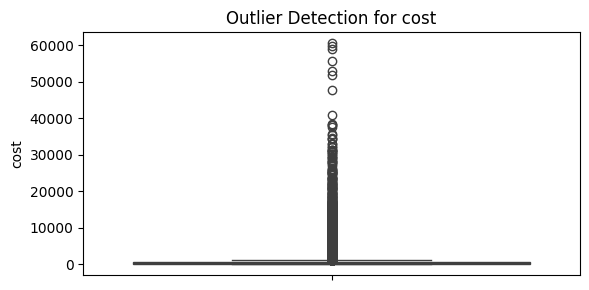

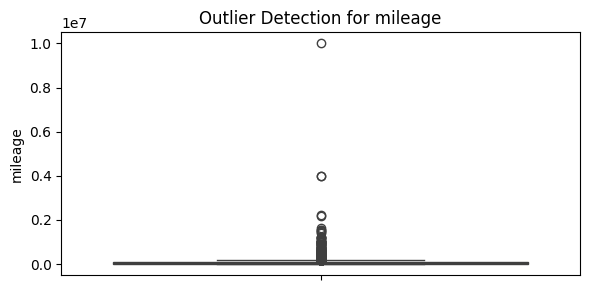

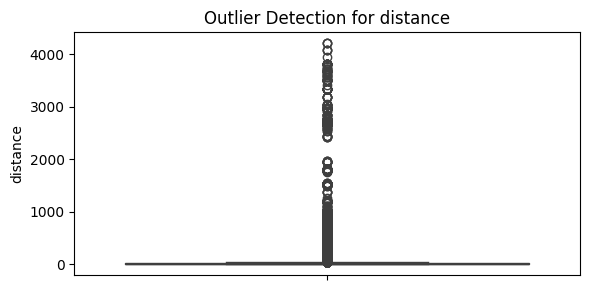

In [ ]:
numeric_cols = ["cost", "mileage", "distance"]

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(y=goauto_df[col])
    plt.title(f"Outlier Detection for {col}")
    plt.tight_layout()
    plt.show()


In [ ]:
Q1 = goauto_df["cost"].quantile(0.25)
Q3 = goauto_df["cost"].quantile(0.75)
IQR = Q3 - Q1

lower_cost = Q1 - 1.5 * IQR
upper_cost = Q3 + 1.5 * IQR

goauto_df["cost_winsorized"] = goauto_df["cost"].clip(
    lower=lower_cost,
    upper=upper_cost)


In [ ]:
Q3_m = goauto_df["mileage"].quantile(0.75)
IQR_m = goauto_df["mileage"].quantile(0.75) - goauto_df["mileage"].quantile(0.25)
upper_mileage = Q3_m + 1.5 * IQR_m

goauto_df["mileage_capped"] = goauto_df["mileage"].clip(upper=upper_mileage)


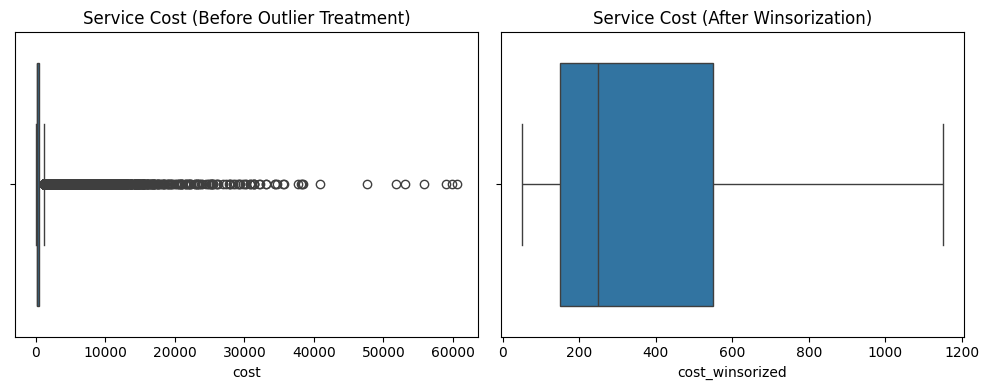

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=goauto_df["cost"])
plt.title("Service Cost (Before Outlier Treatment)")

plt.subplot(1,2,2)
sns.boxplot(x=goauto_df["cost_winsorized"])
plt.title("Service Cost (After Winsorization)")

plt.tight_layout()
plt.show()


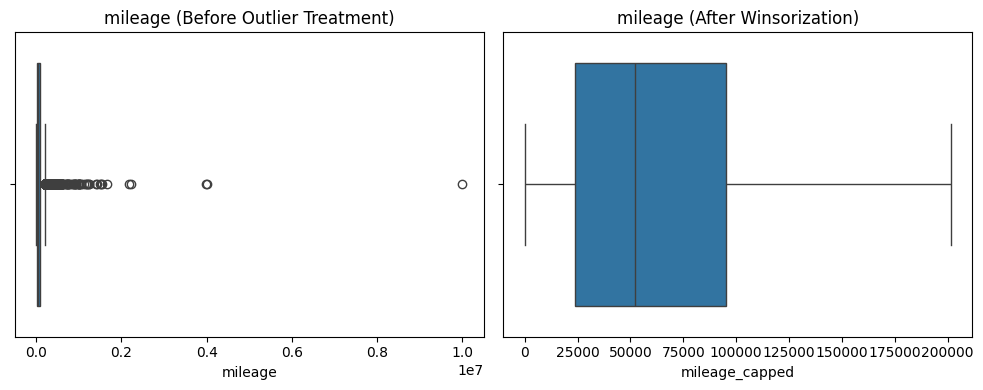

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=goauto_df["mileage"])
plt.title("mileage (Before Outlier Treatment)")

plt.subplot(1,2,2)
sns.boxplot(x=goauto_df["mileage_capped"])
plt.title("mileage (After Winsorization)")

plt.tight_layout()
plt.show()


# Visualisations

## To show how much revenue they generate from customer and service pay

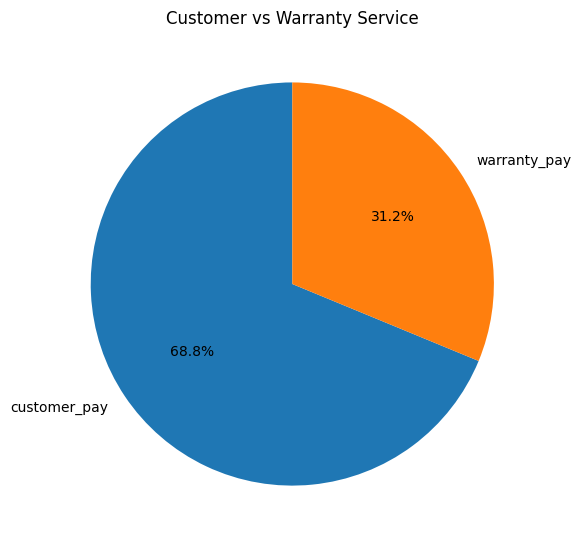

In [ ]:
payment_mix = goauto_df[["customer_pay", "warranty_pay"]].sum()

plt.figure(figsize=(6,6))
payment_mix.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Customer vs Warranty Service")
plt.ylabel("")
plt.tight_layout()
plt.show()


##Average of gross revenue per service

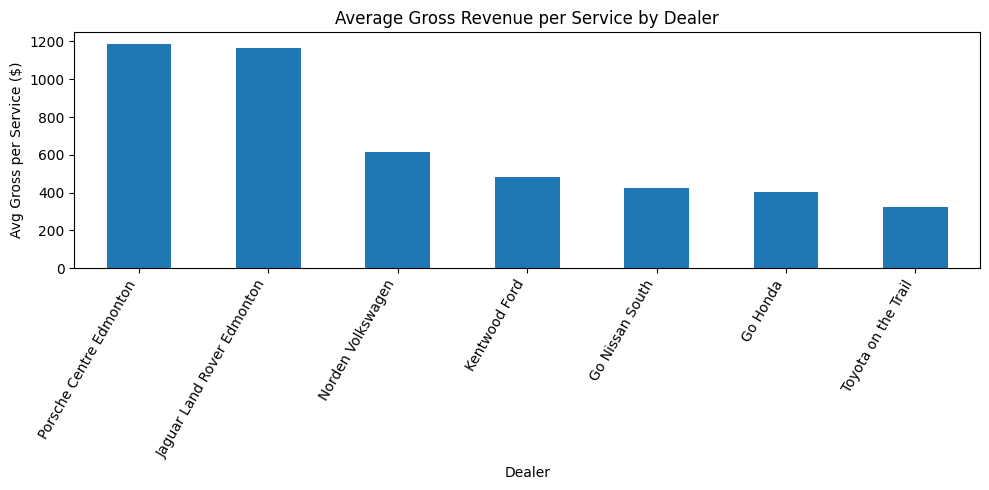

In [ ]:
dealer_efficiency = (goauto_df.groupby("dealer_name")["cost"].mean().sort_values(ascending=False))
plt.figure(figsize=(10,5))
dealer_efficiency.plot(kind="bar")
plt.title("Average Gross Revenue per Service by Dealer")
plt.xlabel("Dealer")
plt.ylabel("Avg Gross per Service ($)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


Had to create this so that the values represented in the visulaisations are the ones that needed.

In [ ]:
valid_df = goauto_df[goauto_df["service Year"].between(2020, 2024)]


##Monthly services trend

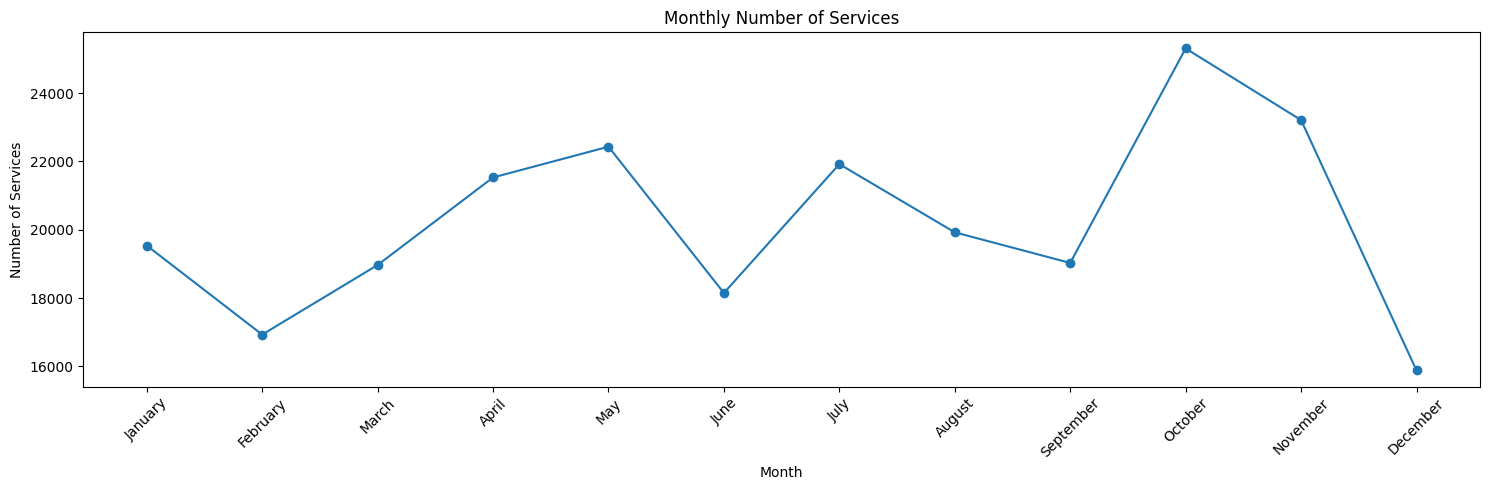

In [ ]:
monthly_services = (goauto_df.groupby("Month_Name").size().reset_index(name="Number_of_services"))
month_order = ["January", "February", "March", "April", "May", "June","July", "August", "September", "October", "November", "December"]

monthly_services["Month_Name"] = pd.Categorical(monthly_services["Month_Name"],categories=month_order,ordered=True)

monthly_services = monthly_services.sort_values("Month_Name")

plt.figure(figsize=(15,5))
plt.plot(monthly_services["Month_Name"],
    monthly_services["Number_of_services"],
    marker="o")
plt.title("Monthly Number of Services")
plt.xlabel("Month")
plt.ylabel("Number of Services")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##Average gross revenue per service for each month and how the trend changes

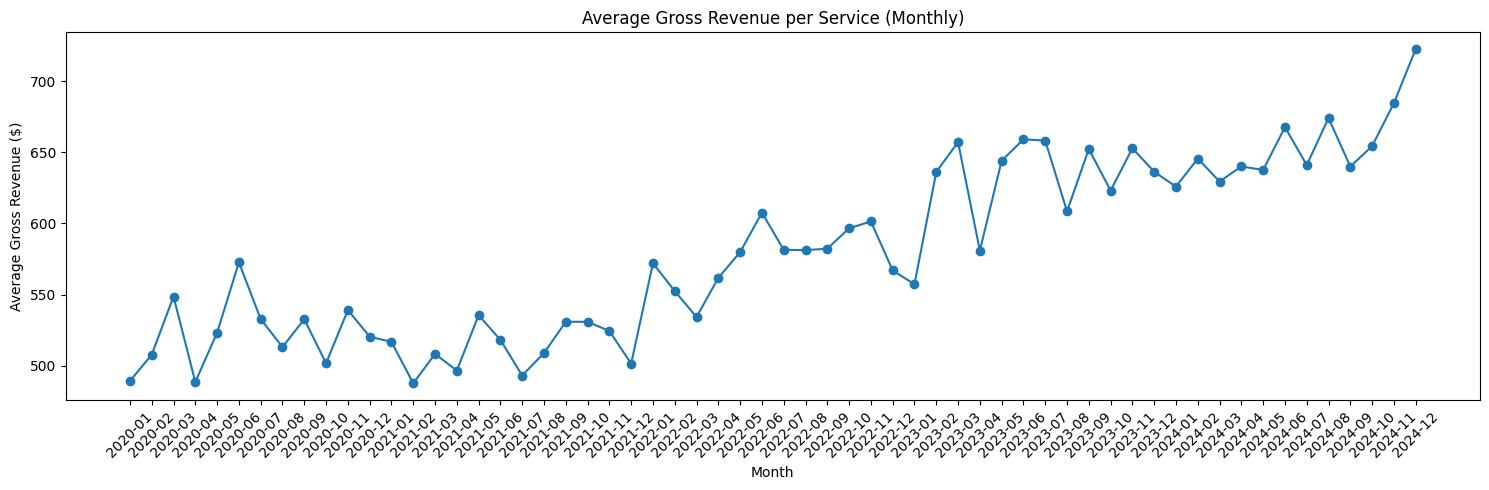

In [ ]:
avg_gross_monthly = (valid_df.groupby("YearMonth")["cost"].mean().reset_index(name="Avg_gross_per_service"))

plt.figure(figsize=(15,5))
plt.plot(avg_gross_monthly["YearMonth"],avg_gross_monthly["Avg_gross_per_service"],marker="o")
avg_gross_monthly["YearMonth_str"] = avg_gross_monthly["YearMonth"].astype(str)


plt.title("Average Gross Revenue per Service (Monthly)")
plt.xlabel("Month")
plt.ylabel("Average Gross Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


##Total gross revenue for each dealership

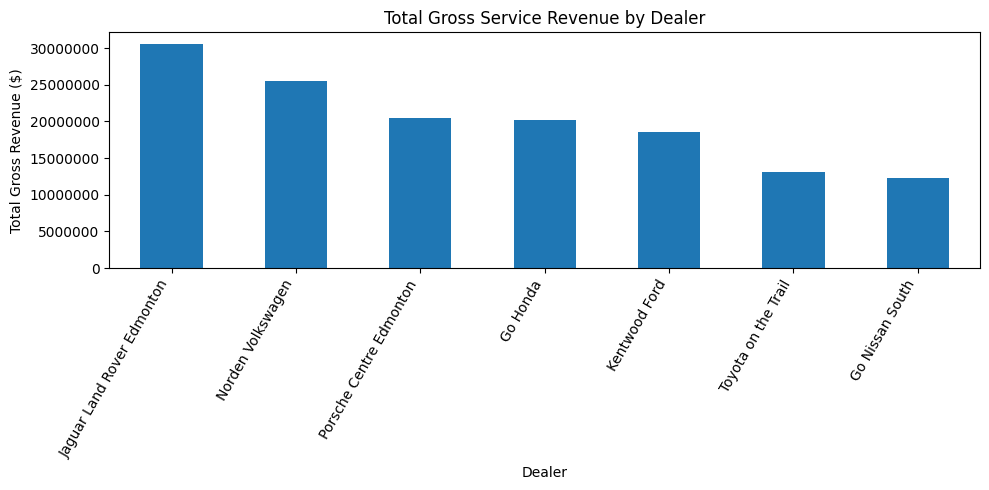

In [ ]:
dealer_revenue = (goauto_df.groupby("dealer_name")["cost"].sum().sort_values(ascending=False))

plt.figure(figsize=(10,5))
dealer_revenue.plot(kind="bar")
plt.title("Total Gross Service Revenue by Dealer")
plt.xlabel("Dealer")
plt.ylabel("Total Gross Revenue ($)")
plt.xticks(rotation=60, ha="right")
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()



##Visualisations for loyalty card

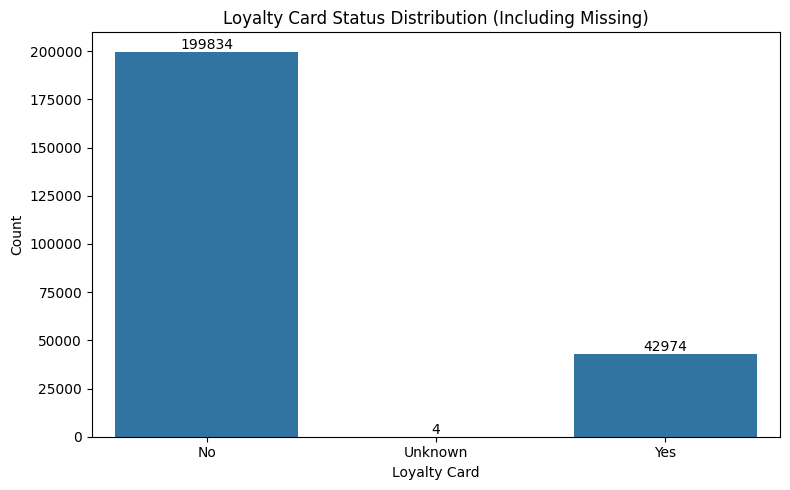

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=goauto_df, x="loyalty_card")

ax.bar_label(ax.containers[0])

plt.title("Loyalty Card Status Distribution (Including Missing)")
plt.xlabel("Loyalty Card")
plt.ylabel("Count")

plt.tight_layout()
plt.show()



## V for Mileage

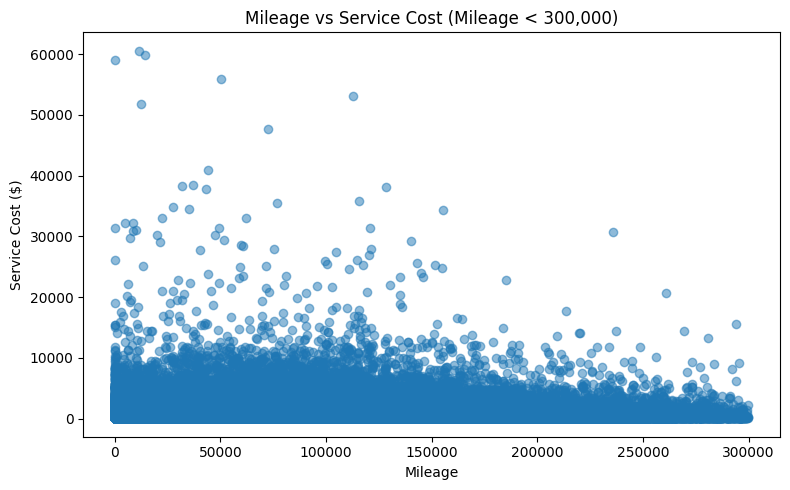

In [ ]:
filtered_df = goauto_df[goauto_df["mileage"] < 300_000]

plt.figure(figsize=(8,5))
plt.scatter(filtered_df["mileage"], filtered_df["cost"], alpha=0.5)
plt.title("Mileage vs Service Cost (Mileage < 300,000)")
plt.xlabel("Mileage")
plt.ylabel("Service Cost ($)")
plt.tight_layout()
plt.show()


## Correlation Heat Map

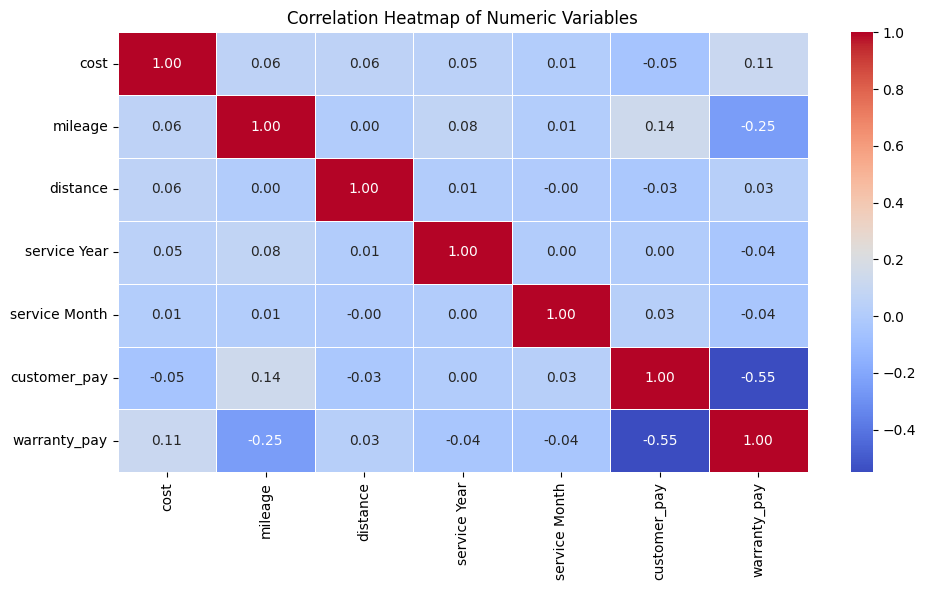

In [ ]:
corr_df = goauto_df[["cost","mileage","distance","service Year","service Month","customer_pay","warranty_pay"]].copy()

corr_df = corr_df.dropna()

corr_matrix = corr_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5)

plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()


##Average of service cost for each car model

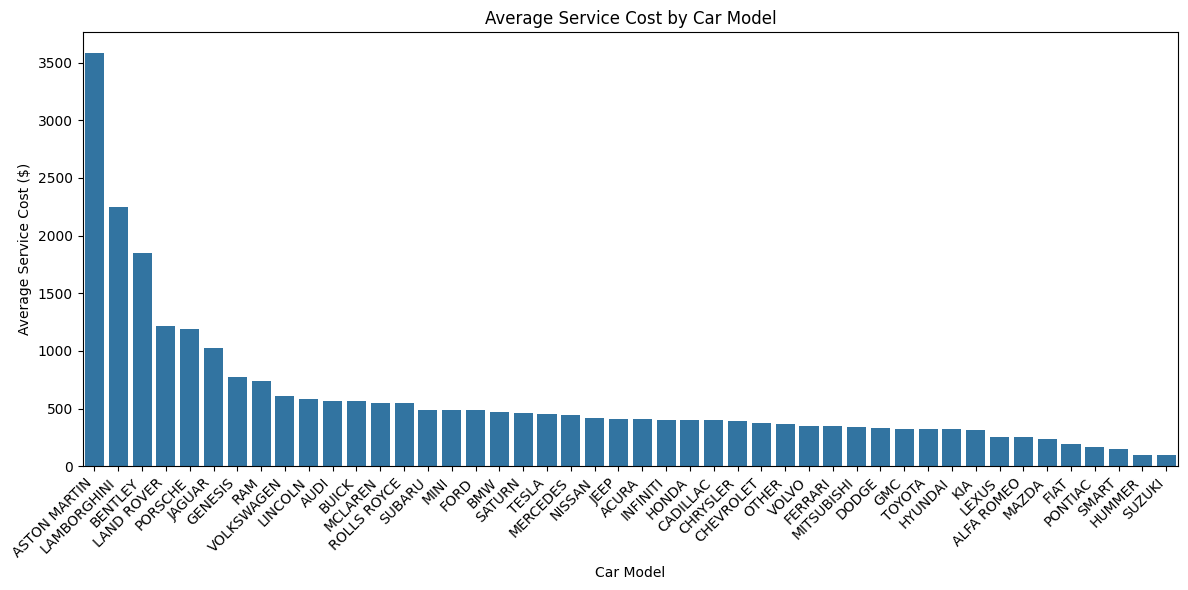

In [ ]:
model_cost = (goauto_df.groupby("make")["cost"].mean().reset_index().sort_values("cost", ascending=False))

plt.figure(figsize=(12,6))
sns.barplot(data=model_cost, x="make", y="cost")

plt.title("Average Service Cost by Car Model")
plt.xlabel("Car Model")
plt.ylabel("Average Service Cost ($)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


##Number of services for each dealer

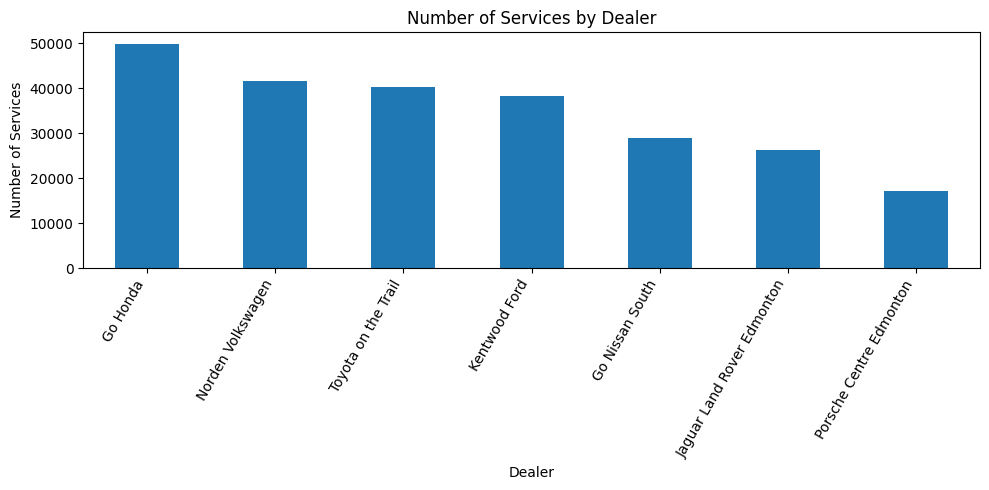

In [ ]:
services_per_dealer = (goauto_df.groupby("dealer_name").size().sort_values(ascending=False))

plt.figure(figsize=(10,5))
services_per_dealer.plot(kind="bar")
plt.title("Number of Services by Dealer")
plt.xlabel("Dealer")
plt.ylabel("Number of Services")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


##Monthly number of services

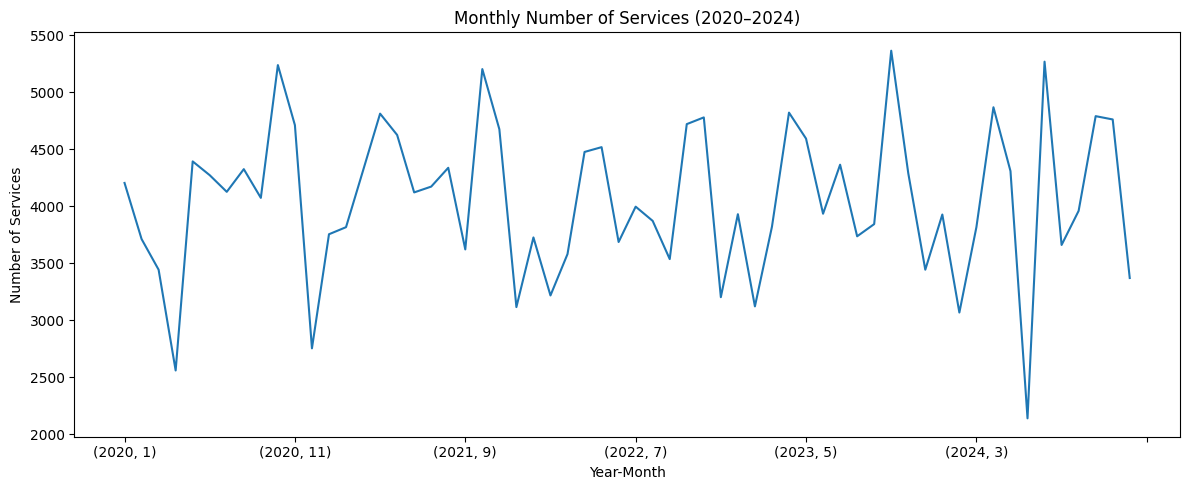

In [ ]:
monthly_services = (valid_df.groupby(["service Year", "service Month"]).size())

plt.figure(figsize=(12,5))
monthly_services.plot()
plt.title("Monthly Number of Services (2020–2024)")
plt.xlabel("Year-Month")
plt.ylabel("Number of Services")
plt.tight_layout()
plt.show()


##Top 10 most serviced car model

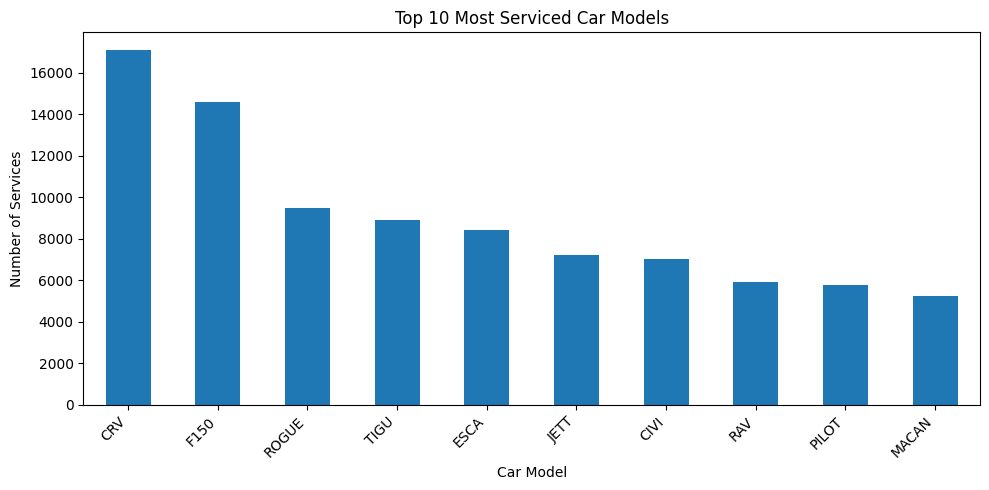

In [ ]:
top_models = (goauto_df["model"].value_counts().head(10))

plt.figure(figsize=(10,5))
top_models.plot(kind="bar")
plt.title("Top 10 Most Serviced Car Models")
plt.xlabel("Car Model")
plt.ylabel("Number of Services")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


##services cost by loyalty card status

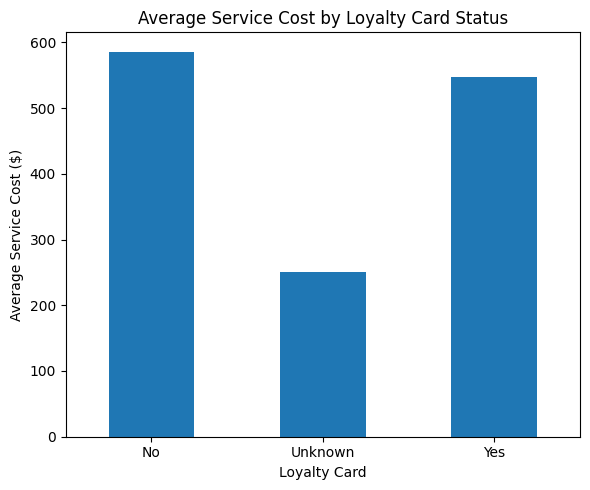

In [ ]:
loyalty_avg_cost = (goauto_df.groupby("loyalty_card")["cost"].mean())

plt.figure(figsize=(6,5))
loyalty_avg_cost.plot(kind="bar")
plt.title("Average Service Cost by Loyalty Card Status")
plt.xlabel("Loyalty Card")
plt.ylabel("Average Service Cost ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


##Top 12 car models by number of services

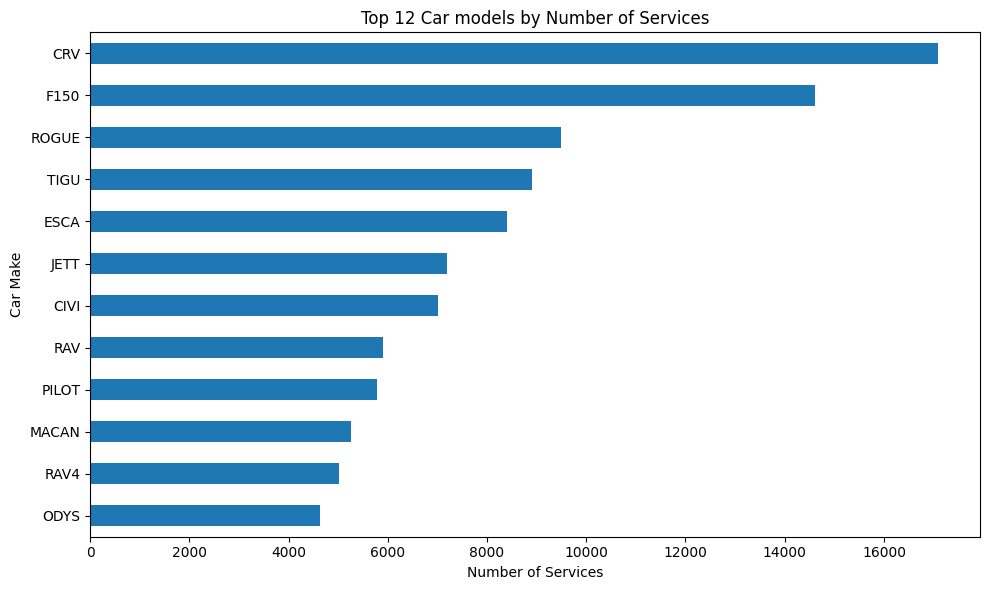

In [ ]:
top_makes = goauto_df["model"].value_counts().head(12)

plt.figure(figsize=(10,6))
top_makes.sort_values().plot(kind="barh")
plt.title("Top 12 Car models by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Car Make")
plt.tight_layout()
plt.show()


##Top 10 Car companies by number of services

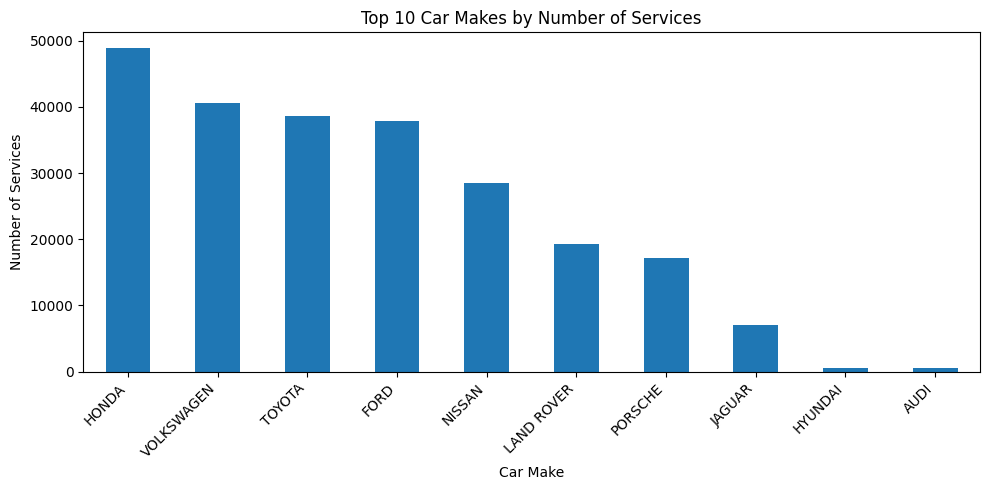

In [ ]:
top_makes = (goauto_df["make"].value_counts().head(10))

plt.figure(figsize=(10,5))
top_makes.plot(kind="bar")
plt.title("Top 10 Car Makes by Number of Services")
plt.xlabel("Car Make")
plt.ylabel("Number of Services")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


##Map that shows the location for each dealership with thier total service revenue

In [ ]:
!pip install folium
import folium

goauto_df["dealer_clean"] = (goauto_df["dealer_name"].str.lower().str.strip())

dealer_locations = {
    "go honda": (53.5443427, -113.6413538),
    "go nissan south": (53.421200, -113.490612),
    "jaguar land rover edmonton": (53.558924, -113.616541),
    "kentwood ford": (53.593957, -113.493215),
    "norden volkswagen": (53.598599, -113.576000),
    "porsche centre edmonton": (53.540404, -113.636532),
    "toyota on the trail": (53.490000, -113.496000)}

edmonton_revenue = (goauto_df.groupby("dealer_clean")["cost"].sum().reset_index())

m = folium.Map(location=[53.5461, -113.4938], zoom_start=11)

for _, row in edmonton_revenue.iterrows():
    dealer = row["dealer_clean"]
    revenue = row["cost"]

    if dealer in dealer_locations:
        lat, lon = dealer_locations[dealer]

        folium.CircleMarker(
            location=[lat, lon],
            radius=max(6, revenue / 1_000_000),
            popup=f"""
            <b>{dealer.title()}</b><br>
            Total Service Revenue: ${revenue:,.0f}
            """,
            color="blue",
            fill=True,
            fill_opacity=0.7).add_to(m)
m

In [ ]:
goauto_df["service_date"] = pd.to_datetime(goauto_df["service_date"], errors="coerce")
goauto_df = goauto_df.dropna(subset=["service_date","cost"])

goauto_df["service_year"]  = goauto_df["service_date"].dt.year.astype(int)
goauto_df["service_month"] = goauto_df["service_date"].dt.month.astype(int)

monthly_df = (goauto_df.groupby(["dealer_name","service_year","service_month"], as_index=False).agg(
        total_revenue=("cost","sum"),
        service_count=("cost","size"),
        avg_revenue_per_service=("cost","mean")))

In [ ]:
monthly_df = monthly_df.sort_values(["dealer_name","service_year","service_month"])
monthly_df["revenue_lag1"] = monthly_df.groupby("dealer_name")["total_revenue"].shift(1)
monthly_df["revenue_lag3"] = monthly_df.groupby("dealer_name")["total_revenue"].shift(3)
monthly_df["revenue_roll3"] = (monthly_df.groupby("dealer_name")["total_revenue"]
                               .shift(1).rolling(3).mean())
monthly_df = monthly_df.dropna()

In [ ]:
monthly_df["revenue_lag1"] = (
    monthly_df.groupby("dealer_name")["total_revenue"].shift(1))

monthly_df["revenue_lag3"] = (
    monthly_df.groupby("dealer_name")["total_revenue"].shift(3))

monthly_df["revenue_roll3"] = (
    monthly_df.groupby("dealer_name")["total_revenue"]
    .shift(1)
    .rolling(3)
    .mean())

In [ ]:
monthly_df = monthly_df.dropna()

In [ ]:
monthly_df = pd.get_dummies(
    monthly_df,
    columns=["dealer_name"],
    drop_first=True)

In [ ]:
X = monthly_df.drop(columns=["total_revenue"])
y = monthly_df["total_revenue"]

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import numpy as np

target_col = "total_revenue"

tscv = TimeSeriesSplit(n_splits=5)
r2_scores = []

for train_idx, test_idx in tscv.split(monthly_df):
    train_df = monthly_df.iloc[train_idx]
    test_df  = monthly_df.iloc[test_idx]

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col]

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train,y_train)

lr_pred = lr_model.predict(X_test)

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200)

rf_model.fit(X_train,y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
def evaluate(y_true,y_pred,name):

    mae = mean_absolute_error(y_true,y_pred)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    r2 = r2_score(y_true,y_pred)

    print(f"{name}")
    print("MAE:",mae)
    print("RMSE:",rmse)
    print("R2:",r2)
    print()

In [ ]:
evaluate(y_test,lr_pred,"Linear Regression")

evaluate(y_test,rf_pred,"Random Forest")

Linear Regression
MAE: 54679.99566413687
RMSE: 66979.11327027432
R2: 0.662697652740188

Random Forest
MAE: 56410.583333333336
RMSE: 67056.19628064193
R2: 0.6619208361987037



In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,)

gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

mae = mean_absolute_error(y_test, gbr_pred)
rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
r2 = r2_score(y_test, gbr_pred)

print("Gradient Boosting")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Gradient Boosting
MAE: 42539.847663601235
RMSE: 53243.86175415643
R2: 0.7868527811339951


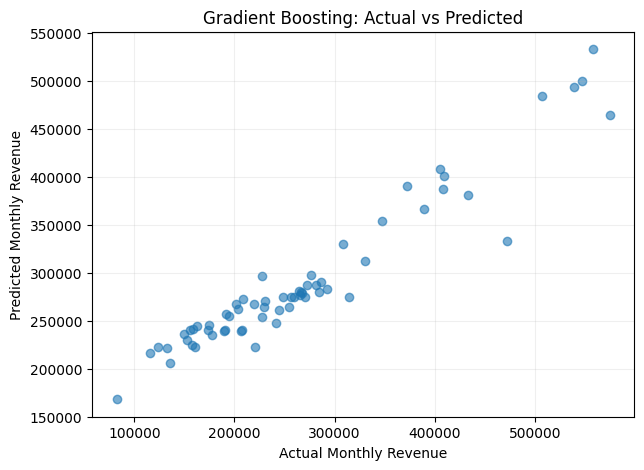

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, gbr_pred, alpha=0.6)
plt.xlabel("Actual Monthly Revenue")
plt.ylabel("Predicted Monthly Revenue")
plt.title("Gradient Boosting: Actual vs Predicted")
plt.grid(True, alpha=0.2)
plt.show()

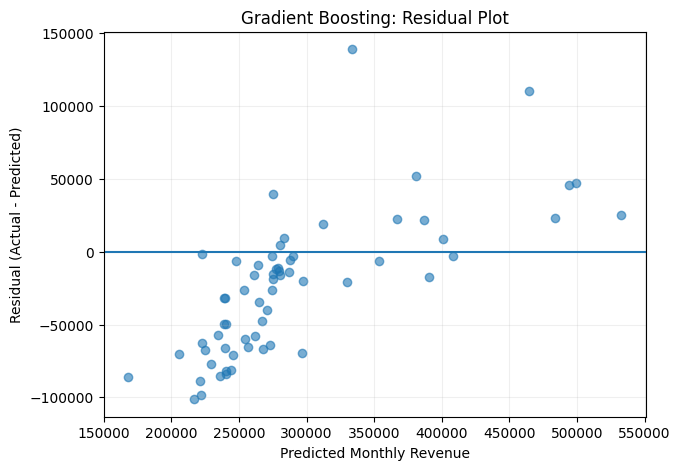

In [ ]:
residuals = y_test - gbr_pred

plt.figure(figsize=(7,5))
plt.scatter(gbr_pred, residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted Monthly Revenue")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Gradient Boosting: Residual Plot")
plt.grid(True, alpha=0.2)
plt.show()

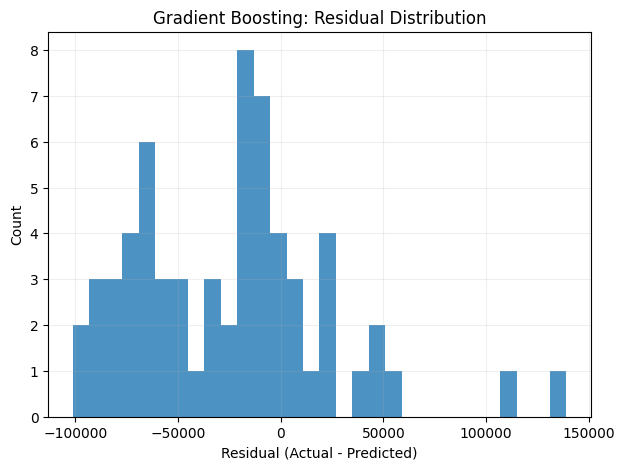

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30, alpha=0.8)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Gradient Boosting: Residual Distribution")
plt.grid(True, alpha=0.2)
plt.show()

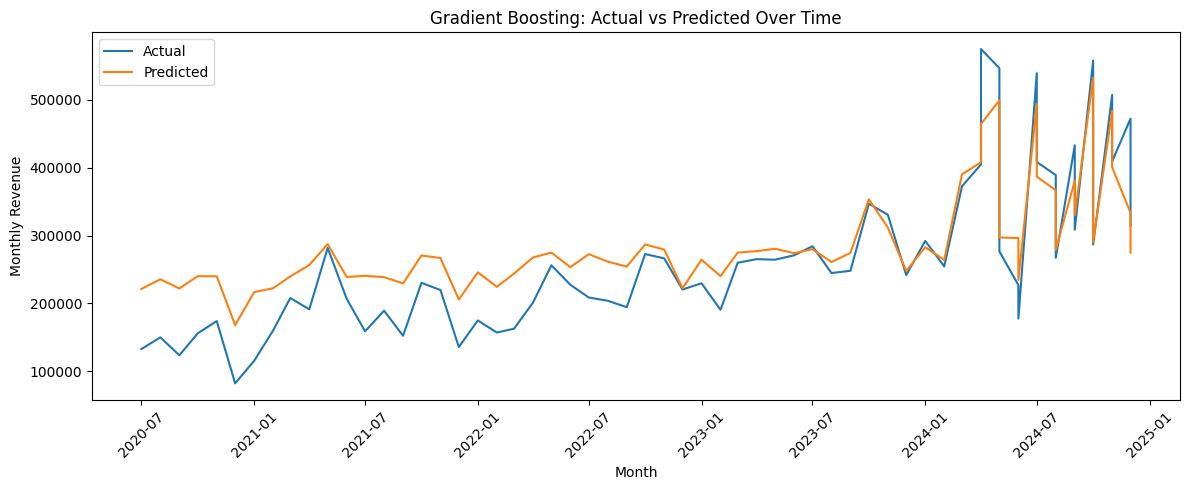

In [ ]:
test_plot = X_test.copy()
test_plot["Actual"] = y_test.values
test_plot["Predicted"] = gbr_pred

test_plot["date"] = pd.to_datetime(test_plot["service_year"].astype(str) + "-" + test_plot["service_month"].astype(str) + "-01")

test_plot = test_plot.sort_values("date")

plt.figure(figsize=(12,5))
plt.plot(test_plot["date"], test_plot["Actual"], label="Actual")
plt.plot(test_plot["date"], test_plot["Predicted"], label="Predicted")
plt.xlabel("Month")
plt.ylabel("Monthly Revenue")
plt.title("Gradient Boosting: Actual vs Predicted Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
test_plot = X_test.copy()
test_plot["Actual"] = y_test.values
test_plot["Predicted"] = gbr_pred
test_plot["AbsError"] = (test_plot["Actual"] - test_plot["Predicted"]).abs()


test_plot["date"] = pd.to_datetime(test_plot["service_year"].astype(str) + "-" + test_plot["service_month"].astype(str) + "-01")

top_bad = test_plot.sort_values("AbsError", ascending=False).head(10)[["date","Actual","Predicted","AbsError"]]
top_good = test_plot.sort_values("AbsError", ascending=True).head(10)[["date","Actual","Predicted","AbsError"]]

display(top_bad)
display(top_good)

,date,Actual,Predicted,AbsError
359,2024-12-01,472400,333453.092853,138946.907147
351,2024-04-01,574950,464571.805361,110378.194639
372,2021-01-01,115400,216661.294040,101261.294040
368,2020-09-01,123650,222065.477667,98415.477667
366,2020-07-01,132850,221408.960114,88558.960114
371,2020-12-01,82250,168080.829101,85830.829101
367,2020-08-01,150000,235641.624666,85641.624666
369,2020-10-01,155950,240229.548426,84279.548426
378,2021-07-01,158950,240782.845235,81832.845235
386,2022-03-01,162800,243962.776244,81162.776244


,date,Actual,Predicted,AbsError
395,2022-12-01,220550,222443.899780,1893.899780
411,2024-04-01,405000,407991.375307,2991.375307
401,2023-06-01,271000,274111.693225,3111.693225
417,2024-10-01,286900,290051.782872,3151.782872
402,2023-07-01,284350,280054.069769,4295.930231
376,2021-05-01,281850,287482.074144,5632.074144
407,2023-12-01,241800,247933.830397,6133.830397
405,2023-10-01,347000,353494.377419,6494.377419
418,2024-11-01,409300,400769.869224,8530.130776
408,2024-01-01,292200,282988.015464,9211.984536
